# Setup

## 1. Setup do ambiente

Instala o `pysus`, que baixa e converte os
arquivos do DATASUS e os pacotes necessários.


In [2]:
!pip install readdbc dbfread
!pip install "numpy<2.3"

import os
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)

print("[INFO] Ambiente de trabalho configurado.")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 479.4/479.4 kB 9.0 MB/s eta 0:00:00
  Created wheel for simpledbf: filename=simpledbf-0.2.6-py3-none-any.whl size=13825 sha256=846a93e02cc67c7b0f76b8a0c96deb0d64a75b3abf48532db882645c14a23f6c
  Stored in directory: /root/.cache/pip/wheels/ee/4b/81/6db04a37ee301f2620476c88f4583c8fd86afb59758d1f0d85
Successfully built simpledbf
  Attempting uninstall: cffi
    Found existing installation: cffi 2.1.1
    Uninstalling cffi-2.1.1:
      Successfully uninstalled cffi-2.1.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
curl-cffi 0.16.3 requires cffi>=2.0.0, but you have cffi 1.17.1 which is incompatible.
cryptography 50.0.2 requires cffi>=2.0.0; platform_python_implementation != "PyPy", but you have cffi 1.17.1 which is incompatible.
pygit2 1.20.1 requires cffi>=2.0, but you have cf

*texto em itálico*# Nova seção

---
## 2. Dicionário de dados

A célula abaixo grava o arquivo `sinan_dic.py` no ambiente do Colab.

Transcrito do **Dicionário de Dados SINAN NET 5.1**

In [3]:
%%writefile sinan_dic.py
"""
Dicionário de dados — SINAN / Violência Interpessoal e Autoprovocada
"""

YES_NO = {"1": "Sim", "2": "Não", "9": "Ignorado"}
YES_NO_NA = {"1": "Sim", "2": "Não", "8": "Não se aplica", "9": "Ignorado"}

LABELS = {
    # --- notificação ---
    "SG_UF_NOT": "UF de notificação",

    # --- vítima ---
    "NU_IDADE_N": "Idade (codificada)",
    "CS_SEXO": "Sexo",
    "CS_RACA": "Raça/cor",
    "CS_ESCOL_N": "Escolaridade",
    "SIT_CONJUG": "Situação conjugal",

    # --- residência ---
    "SG_UF": "UF de residência",

    # --- deficiência e transtorno ---
    "DEF_TRANS": "Possui deficiência ou transtorno",
    "DEF_FISICA": "Deficiência física",
    "DEF_MENTAL": "Deficiência intelectual",
    "DEF_VISUAL": "Deficiência visual",
    "DEF_AUDITI": "Deficiência auditiva",
    "TRAN_MENT": "Transtorno mental",
    "TRAN_COMP": "Transtorno de comportamento",
    "DEF_OUT": "Outras deficiências ou síndromes",

    # --- ocorrência ---
    "SG_UF_OCOR": "UF de ocorrência",
    "LOCAL_OCOR": "Local de ocorrência",

    # --- caracterização da violência ---
    "OUT_VEZES": "Violência de repetição",
    "LES_AUTOP": "Lesão autoprovocada",
    "VIOL_MOTIV": "Violência motivada por",
    "VIOL_FISIC": "Violência física",
    "VIOL_PSICO": "Violência psicológica/moral",
    "VIOL_TORT": "Tortura",
    "VIOL_SEXU": "Violência sexual",
    "VIOL_TRAF": "Tráfico de seres humanos",
    "VIOL_FINAN": "Violência financeira/econômica",
    "VIOL_NEGLI": "Negligência/abandono",
    "VIOL_LEGAL": "Intervenção legal",
    "VIOL_OUTR": "Outro tipo de violência",

    # --- meio de agressão ---
    "AG_FORCA": "Meio — força corporal/espancamento",
    "AG_ENFOR": "Meio — enforcamento",
    "AG_OBJETO": "Meio — objeto contundente",
    "AG_CORTE": "Meio — objeto perfurocortante",
    "AG_QUENTE": "Meio — substância/objeto quente",
    "AG_ENVEN": "Meio — envenenamento/intoxicação",
    "AG_FOGO": "Meio — arma de fogo",
    "AG_AMEACA": "Meio — ameaça",
    "AG_OUTROS": "Meio — outro",

    # --- provável autor ---
    "NUM_ENVOLV": "Número de envolvidos",
    "REL_PAI": "Autor — pai",
    "REL_MAE": "Autor — mãe",
    "REL_PAD": "Autor — padrasto",
    "REL_MAD": "Autor — madrasta",
    "REL_CONJ": "Autor — cônjuge",
    "REL_EXCON": "Autor — ex-cônjuge",
    "REL_NAMO": "Autor — namorado(a)",
    "REL_EXNAM": "Autor — ex-namorado(a)",
    "REL_FILHO": "Autor — filho(a)",
    "REL_IRMAO": "Autor — irmão(ã)",
    "REL_CONHEC": "Autor — amigo/conhecido",
    "REL_DESCO": "Autor — desconhecido",
    "REL_CUIDA": "Autor — cuidador",
    "REL_PATRAO": "Autor — patrão/chefe",
    "REL_INST": "Autor — relação institucional",
    "REL_POL": "Autor — policial/agente da lei",
    "REL_PROPRI": "Autor — a própria pessoa",
    "REL_OUTROS": "Autor — outros",
    "AUTOR_SEXO": "Sexo do provável autor",
    "AUTOR_ALCO": "Suspeita de uso de álcool pelo autor",
}

CATEGORIES = {
    "CS_SEXO": {"M": "Masculino", "F": "Feminino", "I": "Ignorado"},

    "CS_RACA": {
        "1": "Branca", "2": "Preta", "3": "Amarela",
        "4": "Parda", "5": "Indígena", "9": "Ignorado",
    },


    "CS_ESCOL_N": {
        "0": "Analfabeto",
        "1": "1ª a 4ª série incompleta do EF",
        "2": "4ª série completa do EF",
        "3": "5ª a 8ª série incompleta do EF",
        "4": "Ensino fundamental completo",
        "5": "Ensino médio incompleto",
        "6": "Ensino médio completo",
        "7": "Educação superior incompleta",
        "8": "Educação superior completa",
        "9": "Ignorado",
        "10": "Não se aplica",
    },

    "SIT_CONJUG": {
        "1": "Solteiro", "2": "Casado/união consensual", "3": "Viúvo",
        "4": "Separado", "8": "Não se aplica", "9": "Ignorado",
    },

    "LOCAL_OCOR": {
        "01": "Residência", "02": "Habitação coletiva", "03": "Escola",
        "04": "Local de prática esportiva", "05": "Bar ou similar",
        "06": "Via pública", "07": "Comércio/serviços",
        "08": "Indústrias/construção", "09": "Outro", "99": "Ignorado",
    },

    "VIOL_MOTIV": {
        "01": "Sexismo",
        "02": "Homofobia/lesbofobia/bifobia/transfobia",
        "03": "Racismo",
        "04": "Intolerância religiosa",
        "05": "Xenofobia",
        "06": "Conflito geracional",
        "07": "Situação de rua",
        "08": "Deficiência",
        "09": "Outros",
        "88": "Não se aplica",
        "99": "Ignorado",
    },

    "NUM_ENVOLV": {"1": "Um", "2": "Dois ou mais", "9": "Ignorado"},

    "AUTOR_SEXO": {
        "1": "Masculino", "2": "Feminino",
        "3": "Ambos os sexos", "9": "Ignorado",
    },
}

# Campos Sim/Não/Ignorado
_YES_NO_FIELDS = [
    "OUT_VEZES", "DEF_TRANS",
    "VIOL_FISIC", "VIOL_PSICO", "VIOL_TORT", "VIOL_SEXU", "VIOL_TRAF",
    "VIOL_FINAN", "VIOL_NEGLI", "VIOL_LEGAL", "VIOL_OUTR",
    "AG_FORCA", "AG_ENFOR", "AG_OBJETO", "AG_CORTE", "AG_QUENTE",
    "AG_ENVEN", "AG_FOGO", "AG_AMEACA", "AG_OUTROS",
    "REL_PAI", "REL_MAE", "REL_PAD", "REL_MAD", "REL_CONJ", "REL_EXCON",
    "REL_NAMO", "REL_EXNAM", "REL_FILHO", "REL_IRMAO", "REL_CONHEC",
    "REL_DESCO", "REL_CUIDA", "REL_PATRAO", "REL_INST", "REL_POL","REL_PROPRI",
    "REL_OUTROS", "AUTOR_ALCO",
]

# Campos que aceitam "Não se aplica"
_YES_NO_NA_FIELDS = [
    "LES_AUTOP",
    "DEF_FISICA", "DEF_MENTAL", "DEF_VISUAL", "DEF_AUDITI",
    "TRAN_MENT", "TRAN_COMP", "DEF_OUT",
]

for _f in _YES_NO_FIELDS:
    CATEGORIES.setdefault(_f, dict(YES_NO))
for _f in _YES_NO_NA_FIELDS:
    CATEGORIES.setdefault(_f, dict(YES_NO_NA))

# Códigos IBGE de UF
UF_CODE = {
    "11": "RO", "12": "AC", "13": "AM", "14": "RR", "15": "PA",
    "16": "AP", "17": "TO",
    "21": "MA", "22": "PI", "23": "CE", "24": "RN", "25": "PB",
    "26": "PE", "27": "AL", "28": "SE", "29": "BA",
    "31": "MG", "32": "ES", "33": "RJ", "35": "SP",
    "41": "PR", "42": "SC", "43": "RS",
    "50": "MS", "51": "MT", "52": "GO", "53": "DF",
}

UF_NAME = {
    "AC": "Acre", "AL": "Alagoas", "AP": "Amapá", "AM": "Amazonas",
    "BA": "Bahia", "CE": "Ceará", "DF": "Distrito Federal",
    "ES": "Espírito Santo", "GO": "Goiás", "MA": "Maranhão",
    "MT": "Mato Grosso", "MS": "Mato Grosso do Sul", "MG": "Minas Gerais",
    "PA": "Pará", "PB": "Paraíba", "PR": "Paraná", "PE": "Pernambuco",
    "PI": "Piauí", "RJ": "Rio de Janeiro", "RN": "Rio Grande do Norte",
    "RS": "Rio Grande do Sul", "RO": "Rondônia", "RR": "Roraima",
    "SC": "Santa Catarina", "SP": "São Paulo", "SE": "Sergipe",
    "TO": "Tocantins",
}


ATRIBUTOS_PROTEGIDOS = ["CS_RACA", "CS_SEXO"]



Writing sinan_dic.py


---
## 3. Configuração

Onde é decidido a idade mínima, o alvo e as colunas relevantes.

In [4]:
YEAR = 2024

MINIMAL_AGE = 60
TARGET = "OUT_VEZES" # Violência de repetição?

# Colunas para processamento
COLUMNS = [
    # --- identificação e alvo ---
    "NU_IDADE_N",
    "OUT_VEZES",
    "SG_UF_OCOR",
    "SG_UF_NOT"
    ,"SG_UF",

    # --- perfil da vítima ---
    "CS_SEXO",
    "CS_RACA",
    "CS_ESCOL_N",
    "SIT_CONJUG",

    # --- deficiência e transtorno ---
    "DEF_TRANS",
    "DEF_FISICA",
    "DEF_MENTAL",
    "DEF_VISUAL",
    "DEF_AUDITI",
    "TRAN_MENT",
    "TRAN_COMP",
    "DEF_OUT",

    # --- contexto da ocorrência ---
    "LOCAL_OCOR",
    "VIOL_MOTIV",
    "LES_AUTOP",

    # --- tipo de violência ---
    "VIOL_FISIC",
    "VIOL_PSICO",
    "VIOL_TORT",
    "VIOL_SEXU",
    "VIOL_TRAF",
    "VIOL_FINAN",
    "VIOL_NEGLI",
    "VIOL_LEGAL",
    "VIOL_OUTR",

    # --- meio de agressão ---
    "AG_FORCA",
    "AG_AMEACA",
    "AG_OBJETO",
    "AG_CORTE",
    "AG_QUENTE",
    "AG_ENFOR",
    "AG_ENVEN",
    "AG_FOGO",
    "AG_OUTROS",

    # --- provável autor ---
    "NUM_ENVOLV",
    "AUTOR_SEXO",
    "AUTOR_ALCO",
    "REL_FILHO",
    "REL_CONJ",
    "REL_EXCON",
    "REL_CUIDA",
    "REL_PAI",
    "REL_MAE",
    "REL_IRMAO",
    "REL_CONHEC",
    "REL_DESCO",
    "REL_INST",
    "REL_PATRAO",
    "REL_POL",
        "REL_PROPRI",
    "REL_NAMO",
    "REL_EXNAM",
    "REL_PAD",
    "REL_MAD",
    "REL_OUTROS",
]

COL_AGE = "NU_IDADE_N"

# Organizando colunas e eliminando duplicatas
COLUMNS = list(dict.fromkeys([COL_AGE, TARGET] + COLUMNS))

# print(f"[DEBUG] Ano: {YEAR} | {len(COLUMNS)} colunas selecionadas")

In [5]:
# Declaração de funções

from sinan_dic import UF_CODE, UF_NAME, LABELS, CATEGORIES

def normalize_code(value):
    """Normalizando valores do .parquet, exemplo: '1', ' 1', 1 ou 1.0 tem que virar o mesmo valor"""
    if pd.isna(value):
        return None
    text = str(value).strip()
    if text.endswith(".0"):
        text = text[:-2]
    return text or None


---
## 4. Download dos microdados

Via FTP, no DATASUS, em `/dissemin/publicos/SINAN/DADOS/FINAIS/VIOLBR<ano>`. Baixado em .dbc e convertido para .parquet para melhor manuseamento dos dados.


In [6]:
import ftplib
import os
import pyarrow.parquet as parq
import pandas as pd
import readdbc
from dbfread import DBF

# Função alternativa por conta de conflito do PySus

def download_sinan_viol(year):
    ftp = ftplib.FTP('ftp.datasus.gov.br')
    ftp.login()

    decade = str(year)[-2:] # Pega os 2 últimos dígitos

    ftp.cwd('/dissemin/publicos/SINAN/DADOS/FINAIS/')

    files = ftp.nlst()
    files_viol = [f for f in files if f.startswith('VIOL') and f.endswith(f'{decade}.dbc')]

    dataframes = []

    for file in files_viol:
        dbc_path = f'/content/{file}'
        dbf_path = f'/content/{file.replace(".dbc", ".dbf")}'

        # Baixa do FTP
        with open(dbc_path, 'wb') as f:
            ftp.retrbinary(f'RETR {file}', f.write)

        # Converte pra DBF
        readdbc.dbc2dbf(dbc_path, dbf_path)

        # Lê pro Pandas
        table = DBF(dbf_path, encoding='latin1')
        df_state = pd.DataFrame(iter(table))
        dataframes.append(df_state)

        os.remove(dbc_path)
        os.remove(dbf_path)

    ftp.quit()

    # Junta todos os estados e e salva em um arquivo parquet
    merged = pd.concat(dataframes, ignore_index=True)
    path_parquet = f'/content/VIOL_{year}.parquet'
    merged.to_parquet(path_parquet)

    return [path_parquet]



In [7]:
# Download

print(f"[INFO] Iniciando download de SINAL/VIOL edição {YEAR}.")

paths = download_sinan_viol(YEAR)

filename = str(paths[0]) if isinstance(paths, list) else str(paths)

print(f"[INFO] Download concluído com sucesso.")

# Validando arquivo
file = parq.ParquetFile(filename)

file_cols = list(file.schema_arrow.names)

missing = [c for c in COLUMNS if c not in file_cols]
if missing:
    print(f"[AVISO] ATENÇÃO — não existem neste arquivo: {missing}")
    COLUMNS = [c for c in COLUMNS if c in file_cols]

raw_data = pd.read_parquet(filename, columns=COLUMNS)

# print(f"[DEBUG] Carregado: {raw_data.shape[0]:,} linhas x {raw_data.shape[1]} colunas")

raw_data.head(1)

[INFO] Iniciando download de SINAL/VIOL edição 2024.
[INFO] Download concluído com sucesso.


,NU_IDADE_N,OUT_VEZES,SG_UF_OCOR,SG_UF_NOT,SG_UF,CS_SEXO,CS_RACA,CS_ESCOL_N,SIT_CONJUG,DEF_TRANS,DEF_FISICA,DEF_MENTAL,DEF_VISUAL,DEF_AUDITI,TRAN_MENT,TRAN_COMP,DEF_OUT,LOCAL_OCOR,VIOL_MOTIV,LES_AUTOP,VIOL_FISIC,VIOL_PSICO,VIOL_TORT,VIOL_SEXU,VIOL_TRAF,VIOL_FINAN,VIOL_NEGLI,VIOL_LEGAL,VIOL_OUTR,AG_FORCA,AG_AMEACA,AG_OBJETO,AG_CORTE,AG_QUENTE,AG_ENFOR,AG_ENVEN,AG_FOGO,AG_OUTROS,NUM_ENVOLV,AUTOR_SEXO,AUTOR_ALCO,REL_FILHO,REL_CONJ,REL_EXCON,REL_CUIDA,REL_PAI,REL_MAE,REL_IRMAO,REL_CONHEC,REL_DESCO,REL_INST,REL_PATRAO,REL_POL,REL_PROPRI,REL_NAMO,REL_EXNAM,REL_PAD,REL_MAD,REL_OUTROS
0,4033,1,52,52,52,F,4,09,2,2,8,8,8,8,8,8,8,01,09,2,2,1,2,2,2,2,2,2,2,2,1,2,2,2,2,2,2,2,1,1,2,2,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2


---
## 5. Filtrar vítimas 60+

Decodificar idade e filtrar apenas pessoas com 60+

### Dicionário

| 1º dígito | Unidade |
|---|---|
| 1 | horas |
| 2 | dias |
| 3 | meses |
| 4 | anos |


In [29]:
age_encoded = pd.to_numeric(raw_data[COL_AGE], errors="coerce")
unit = age_encoded // 1000
quantity = age_encoded % 1000

# Só é idade de interesse quando a unidade é anos
raw_data["Idade"] = quantity.where(unit == 4)

# Filtrando apenas idosos
elderly = raw_data[raw_data["Idade"] >= MINIMAL_AGE].copy()
test = elderly
raw_data["Idade"] = raw_data["Idade"].astype("Int64")

print(f"[INFO] Total de notificações no ano : {len(raw_data):,}")
print(f"[INFO] Vítimas {MINIMAL_AGE}+                  : {len(elderly):,}")
print(f"[INFO] Proporção                    : {len(elderly)/len(raw_data):.1%}")
print(f"\n[INFO] Idade idosos - mín: {elderly['Idade'].min():.0f} | máx: {elderly['Idade'].max():.0f}")

if elderly.empty:
    raise SystemExit(
        "[ERRO] Nenhum registro encontrado. Parando o programa."
    )


[INFO] Total de notificações no ano : 616,548
[INFO] Vítimas 60+                  : 42,176
[INFO] Proporção                    : 6.8%

[INFO] Idade idosos - mín: 60 | máx: 130


---
## 9. Violência autoprovocada

A ficha do SINAN cobre tanto violência interpessoal e a autoprovocada, porém para o treinamento os dados de autolesão precisam sair antes da modelagem.

In [9]:
self_harm = (
    (elderly["REL_PROPRI"].map(normalize_code) == "1")
    | (elderly["LES_AUTOP"].map(normalize_code) == "1")
)

interpersonal = elderly[~self_harm].copy()

print(f"[INFO] Vítimas 60+           : {len(elderly):,}")
print(f"[INFO] Autolesão excluída    : {self_harm.sum():,} ({self_harm.mean():.1%})")
print(f"[INFO] Violência interpessoal: {len(interpersonal):,}")


Vítimas 60+           : 42,176
Autolesão excluída    : 7,033 (16.7%)
Violência interpessoal: 35,143


In [10]:
%%writefile features.py
"""
features.py — engenharia de atributos compartilhada

Este módulo é a ÚNICA fonte da verdade sobre como um caso vira as colunas
que o modelo espera. O notebook de treino e o app Streamlit importam daqui.

Motivo: se a engenharia ficar escrita em dois lugares, treino e produção
divergem com o tempo e o modelo passa a prever errado sem dar erro.
É o problema conhecido como training-serving skew.
"""

import pandas as pd

# Grupos de campos da ficha do SINAN

VIOLENCE_TYPES = [
    "VIOL_FISIC", "VIOL_PSICO", "VIOL_NEGLI", "VIOL_FINAN",
    "VIOL_SEXU", "VIOL_TORT", "VIOL_TRAF", "VIOL_LEGAL",
]

AGGRESSION_MEANS = [
    "AG_FORCA", "AG_AMEACA", "AG_OBJETO", "AG_CORTE",
    "AG_QUENTE", "AG_ENFOR", "AG_ENVEN", "AG_FOGO",
]

FAMILY = [
    "REL_PAI", "REL_MAE", "REL_PAD", "REL_MAD",
    "REL_FILHO", "REL_IRMAO", "REL_CONJ", "REL_EXCON",
]

# Coabitação provável. Ex-cônjuge fica fora por definição.
HOUSEHOLD = ["REL_CONJ", "REL_FILHO", "REL_CUIDA"]

DISABILITY = [
    "DEF_FISICA", "DEF_MENTAL", "DEF_VISUAL", "DEF_AUDITI",
    "TRAN_MENT", "TRAN_COMP", "DEF_OUT",
]

AGE_BINS = [60, 70, 80, 90, 120]
AGE_LABELS = ["60-69", "70-79", "80-89", "90+"]

ENGINEERED = [
    "n_violence_types", "n_aggression_means", "family_aggressor",
    "household_aggressor", "aggressor_identified", "has_disability",
    "age_band",
]

# Normalização

def normalize_code(value):
    """Padroniza o código antes de comparar.

    O parquet traz '1', ' 1', 1 ou 1.0 para o mesmo valor. Sem padronizar,
    a comparação falha em silêncio.
    """
    if pd.isna(value):
        return None
    text = str(value).strip()
    if text.endswith(".0"):
        text = text[:-2]
    return text or None


def _is_yes(df, column):
    """True onde o campo Sim/Não está marcado como Sim (código 1)."""
    if column not in df.columns:
        return pd.Series(False, index=df.index)
    return df[column].map(normalize_code) == "1"

# Engenharia de atributos

def build_features(df):
    """
    Recebe os dados do SINAN e adiciona as colunas transformadas necessárias
    para o treinamento
    """
    out = df.copy()

    # Contagens: violência e meio múltiplos indicam gravidade
    out["n_violence_types"] = sum(
        _is_yes(out, c).astype(int) for c in VIOLENCE_TYPES
    )
    out["n_aggression_means"] = sum(
        _is_yes(out, c).astype(int) for c in AGGRESSION_MEANS
    )

    # Agregação do agressor: o que importa é a categoria, não qual parente
    relations = [c for c in out.columns if c.startswith("REL_")]

    out["family_aggressor"] = sum(
        _is_yes(out, c).astype(int) for c in FAMILY
    ) > 0
    out["household_aggressor"] = sum(
        _is_yes(out, c).astype(int) for c in HOUSEHOLD
    ) > 0
    out["aggressor_identified"] = sum(
        _is_yes(out, c).astype(int) for c in relations
    ) > 0

    out["has_disability"] = sum(
        _is_yes(out, c).astype(int) for c in DISABILITY
    ) > 0

    # Faixa etária: a relação com recorrência pode não ser linear
    out["age_band"] = pd.cut(
        out["Idade"], bins=AGE_BINS, labels=AGE_LABELS, right=False
    ).astype(str)

    return out


def align_to_model(df, pipeline):
    """
    Garante que o DataFrame tem exatamente as colunas que o modelo espera.

    Coluna faltando vira nula e coluna sobrando é descartada.
    """
    expected = list(pipeline.named_steps["prep"].feature_names_in_)

    for column in expected:
        if column not in df.columns:
            df[column] = None

    return df[expected]

Writing features.py


# Treino

---
## 1. Engenharia de atributos

Criação de variáveis que resumem informação espalhada em vários campos.

| Variável | O que captura |
|---|---|
| `n_violence_types` | Número de tipos de violência |
| `n_aggression_means` | Número de tipos de agressões |
| `family_aggressor` | Se o agressor é da família ou não |
| `household_aggressor` | Se o agressor mora com a vítima |
| `aggressor_identified` | Se o agressor foi identificado (não para 13,9% da base) |
| `has_disability` | Se a vítima possuia algum tipo de deficiência |
| `age_band` | Faixa da idade da vítima (60-69, 70-79, 80-89 ou 90+) |


In [11]:
from features import build_features

data = build_features(interpersonal)

# Remove campos nulos
data = data[data["age_band"].notna()].copy()

print(data[["n_violence_types", "n_aggression_means", "family_aggressor",
            "household_aggressor", "aggressor_identified",
            "has_disability"]].describe().T)

                      count      mean       std  min  25%  50%  75%  max
n_violence_types    35143.0  1.221922  0.568415  0.0  1.0  1.0  1.0  8.0
n_aggression_means  35143.0  0.725920  0.776667  0.0  0.0  1.0  1.0  8.0


---
## 2. Definição de X e y

**y** — violência de repetição. Registros com "Ignorado" ou nulo saem, não
se pode definir qual seria a resposta.

**X** — exclusões de variáveis:

- `SG_UF*`: alta cardinalidade e codifica capacidade de notificação do serviço, não risco do caso.
- (`CS_RACA`): reservados para a auditoria de equidade da Sprint 4, fora do treino.
- (`REL_PROPRI`, `LES_AUTOP`): dados de autoprovocação já descartados durante a filtragem, viram apenas não depois da filtragem.
- (`NU_IDADE_N`): substituída por `Idade` e `age_band`.
  


In [12]:
# Salvar as variaveis originais
_original_target_name = "OUT_VEZES"
_original_col_age_name = "NU_IDADE_N"

# Salvar o nome traduzido
target_col_name_in_data = LABELS[_original_target_name]
age_col_name_in_data = 'Idade'

codes = data[TARGET].map(normalize_code)
valid = codes.isin(["1", "2"])

model_data = data[valid].copy()
y = (codes[valid] == "1").astype(int)

DELETE = [
    TARGET, COL_AGE,
    "SG_UF_NOT", "SG_UF", "SG_UF_OCOR",
    "CS_RACA",
    "REL_PROPRI", "LES_AUTOP",
]

X = model_data.drop(columns=DELETE, errors="ignore")

print(f"[INFO] Casos com alvo conhecido: {len(X):,}")
print(f"[INFO] Variáveis               : {X.shape[1]}")
print(f"[INFO] Recorrência (y=1)       : {y.mean():.1%}")
print(f"[INFO] Teto de variáveis       : {min(y.sum(), (1-y).sum()) // 10:,}")

dups = X.duplicated().sum()
print(f"[INFO] Linhas idênticas em X   : {dups:,} ({dups/len(X):.1%})")

Casos com alvo conhecido: 25,056
Variáveis               : 59
Recorrência (y=1)       : 53.3%
Teto de variáveis       : 1,171
Linhas idênticas em X   : 1,039 (4.1%)


---
## 3. Separação treino/teste

Separando os dados, 20% reservado para teste.

In [13]:
from sklearn.model_selection import train_test_split

SEED_TRAINING = 42

# Notificação duplicada dividida entre treino e teste quebra a
# independência do teste: o modelo memoriza em vez de generalizar.
keep = ~X.duplicated()
X_model, y_model = X[keep], y[keep]

print(f"[INFO] Duplicatas removidas: {(~keep).sum():,} ({(~keep).mean():.1%})")
print(f"[INFO] Base de modelagem   : {len(X_model):,}")

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.2, stratify=y_model,
    random_state=SEED_TRAINING
)

print(f"[INFO] Treino: {len(X_train):,}  (recorrência {y_train.mean():.1%})")
print(f"[INFO] Teste : {len(X_test):,}  (recorrência {y_test.mean():.1%})")

Duplicatas removidas: 1,039 (4.1%)
Base de modelagem   : 24,017
Treino: 19,213  (recorrência 54.6%)
Teste : 4,804  (recorrência 54.6%)


## 4. Pré-processamento

Transformando colunas para o treinamento (One-hot encoding)

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric = ["Idade", "n_violence_types", "n_aggression_means"]
numeric = [c for c in numeric if c in X_model.columns]

boolean = ["family_aggressor", "household_aggressor",
            "aggressor_identified", "has_disability"]
boolean = [c for c in boolean if c in X.columns]

categorical = [c for c in X_model.columns if c not in numeric + boolean]

print(f"[INFO] Numéricas   : {len(numeric)}  {numeric}")
print(f"[INFO] Booleanas   : {len(boolean)} {boolean}")
print(f"[INFO] Categóricas : {len(categorical)} {categorical}")

# "Ignorado" é categoria própria
# Só o nulo verdadeiro
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="Sem informação")),
    ("encode", OneHotEncoder(handle_unknown="ignore", drop="first",
                              sparse_output=False)),
])

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

preprocessor = ColumnTransformer([
    ("cat", categorical_pipe, categorical),
    ("num", numeric_pipe, numeric),
    ("bool", "passthrough", boolean),
])

n_features = preprocessor.fit_transform(X_train).shape[1]
print(f"\n[INFO] Após o one-hot: {n_features} colunas")


Numéricas   : 3  ['Idade', 'n_violence_types', 'n_aggression_means']
Booleanas   : 4 ['family_aggressor', 'household_aggressor', 'aggressor_identified', 'has_disability']
Categóricas : 52 ['CS_SEXO', 'CS_ESCOL_N', 'SIT_CONJUG', 'DEF_TRANS', 'DEF_FISICA', 'DEF_MENTAL', 'DEF_VISUAL', 'DEF_AUDITI', 'TRAN_MENT', 'TRAN_COMP', 'DEF_OUT', 'LOCAL_OCOR', 'VIOL_MOTIV', 'VIOL_FISIC', 'VIOL_PSICO', 'VIOL_TORT', 'VIOL_SEXU', 'VIOL_TRAF', 'VIOL_FINAN', 'VIOL_NEGLI', 'VIOL_LEGAL', 'VIOL_OUTR', 'AG_FORCA', 'AG_AMEACA', 'AG_OBJETO', 'AG_CORTE', 'AG_QUENTE', 'AG_ENFOR', 'AG_ENVEN', 'AG_FOGO', 'AG_OUTROS', 'NUM_ENVOLV', 'AUTOR_SEXO', 'AUTOR_ALCO', 'REL_FILHO', 'REL_CONJ', 'REL_EXCON', 'REL_CUIDA', 'REL_PAI', 'REL_MAE', 'REL_IRMAO', 'REL_CONHEC', 'REL_DESCO', 'REL_INST', 'REL_PATRAO', 'REL_POL', 'REL_NAMO', 'REL_EXNAM', 'REL_PAD', 'REL_MAD', 'REL_OUTROS', 'age_band']

Após o one-hot: 197 colunas


## 5. Treinamento e comparação de modelos

Quatro modelos escolhidos:

1. **DummyClassifier** — chuta sempre a classe majoritária.
2. **Regressão logística** — devolve um peso por variável, e o peso é lido diretamente.
3. **Random Forest** — captura interação entre variáveis.
4. **HistGradientBoosting** — usa árvores de decisão sequencialmente. Cada nova árvore é criada para corrigir os erros das anteriores.

| Métrica | O que significa? |
| :--- | :--- |
| **AUC (Área Sob a Curva)** | Mede a capacidade do modelo de distinguir entre as classes. Varia de 0,5 (chute aleatório) a 1,0 (perfeito). |
| **AUC na Validação Cruzada** | A média do AUC após testar o modelo em diferentes partes dos dados. Oferece uma estimativa mais realista e confiável. |
| **Desvio Padrão (Validação Cruzada)**| Mede o quanto o resultado do modelo variou nos testes. Valores baixos indicam que o modelo é estável e consistente. |
| **Acurácia** | Porcentagem total de acertos do modelo. É intuitiva, mas pode ser enganosa se os dados forem muito desbalanceados. |
| **Recall (Revocação)** | De todos os casos que *realmente eram positivos*, quantos o modelo encontrou? Foca em evitar os **falsos negativos** (ex: não deixar passar uma doença). |
| **Precisão** | De todos os casos que o modelo *afirmou ser positivos*, quantos ele acertou? Foca em evitar os **falsos positivos** (ex: não bloquear um cartão de crédito à toa). |

In [27]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score, recall_score, precision_score, accuracy_score

SEED_TRAINING = 42

models = {
    "Baseline (Dummy)": DummyClassifier(strategy="most_frequent"),
    "Regressão logística": LogisticRegression(max_iter=1000, random_state=SEED_TRAINING),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=20, random_state=SEED_TRAINING, n_jobs=-1
    ),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=SEED_TRAINING),
}

results = []
trained = {}

for name, estimator in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", estimator)])
    pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    # Faz AUC no CV também
    cv = cross_val_score(pipe, X_train, y_train, cv=5, scoring="roc_auc")

    results.append({
        "modelo": name,
        "AUC": round(roc_auc_score(y_test, proba), 3),
        "AUC (CV)": round(cv.mean(), 3),
        "desvio CV": round(cv.std(), 3),
        "acurácia": round(accuracy_score(y_test, pred), 3),
        "recall": round(recall_score(y_test, pred), 3),
        "precisão": round(precision_score(y_test, pred, zero_division=0), 3),
    })
    trained[name] = pipe
    print(f"[INFO] {name}: AUC {results[-1]['AUC']}")

comparison = pd.DataFrame(results).sort_values("AUC", ascending=False)
comparison

/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Baseline (Dummy): AUC 0.5


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Regressão logística: AUC 0.825


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Random Forest: AUC 0.83
Gradient Boosting: AUC 0.836


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,modelo,AUC,AUC (CV),desvio CV,acurácia,recall,precisão
3,Gradient Boosting,0.836,0.837,0.005,0.758,0.810,0.762
2,Random Forest,0.830,0.834,0.004,0.760,0.836,0.752
1,Regressão logística,0.825,0.825,0.002,0.751,0.813,0.751
0,Baseline (Dummy),0.500,0.500,0.000,0.546,1.000,0.546


---
## 6. Avaliação

Matriz de confusão e curva ROC do modelo com melhor AUC.

Melhor modelo: Gradient Boosting  (AUC 0.836)
Baseline     : AUC 0.5

[INFO] Ganho sobre o baseline: +0.336

               precision    recall  f1-score   support

Sem repetição       0.75      0.70      0.72      2182
    Repetição       0.76      0.81      0.79      2622

     accuracy                           0.76      4804
    macro avg       0.76      0.75      0.75      4804
 weighted avg       0.76      0.76      0.76      4804



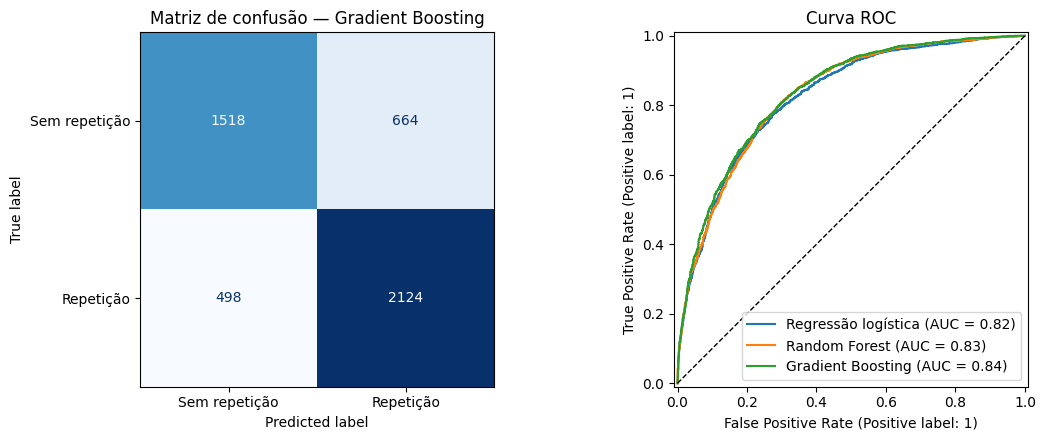

In [16]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              RocCurveDisplay, classification_report)
import matplotlib.pyplot as plt

best_name = comparison[comparison["modelo"] != "Baseline (Dummy)"].iloc[0]["modelo"]
best_model = trained[best_name]

baseline_auc = comparison.loc[comparison["modelo"] == "Baseline (Dummy)", "AUC"].iloc[0]
best_auc = comparison.loc[comparison["modelo"] == best_name, "AUC"].iloc[0]

print(f"[INFO] Melhor modelo: {best_name}  (AUC {best_auc})")
print(f"[INFO] Baseline     : AUC {baseline_auc}")

if best_auc <= baseline_auc + 0.02:
    print("\n[AVISO] O modelo NÃO supera o baseline de forma relevante.")
else:
    print(f"\n[INFO] Ganho sobre o baseline: {best_auc - baseline_auc:+.3f}")
print()

y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred,
                            target_names=["Sem repetição", "Repetição"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["Sem repetição", "Repetição"],
).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Matriz de confusão — {best_name}")

for name, pipe in trained.items():
    if name == "Baseline (Dummy)":
        continue
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=axes[1], name=name)

axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Acaso")
axes[1].set_title("Curva ROC")
plt.tight_layout()


---
## 7. Validação

Fazendo permutation importance, ou seja, embaralhando uma variável por vez e medindo quanto o AUC cai. Se cair muito, a variável influênciava na decisão do AUC.

E depois verificando se algum campo sensível não entrou no modelo.

,variável,nome,queda no AUC,desvio
54,family_aggressor,family_aggressor,0.0274,0.0026
11,LOCAL_OCOR,Local de ocorrência,0.0142,0.0014
13,VIOL_FISIC,Violência física,0.0140,0.0007
23,AG_AMEACA,Meio — ameaça,0.0137,0.0013
14,VIOL_PSICO,Violência psicológica/moral,0.0126,0.0013
3,DEF_TRANS,Possui deficiência ou transtorno,0.0122,0.0013
33,AUTOR_ALCO,Suspeita de uso de álcool pelo autor,0.0111,0.0018
18,VIOL_FINAN,Violência financeira/econômica,0.0091,0.0013
12,VIOL_MOTIV,Violência motivada por,0.0081,0.0012
42,REL_DESCO,Autor — desconhecido,0.0077,0.0012


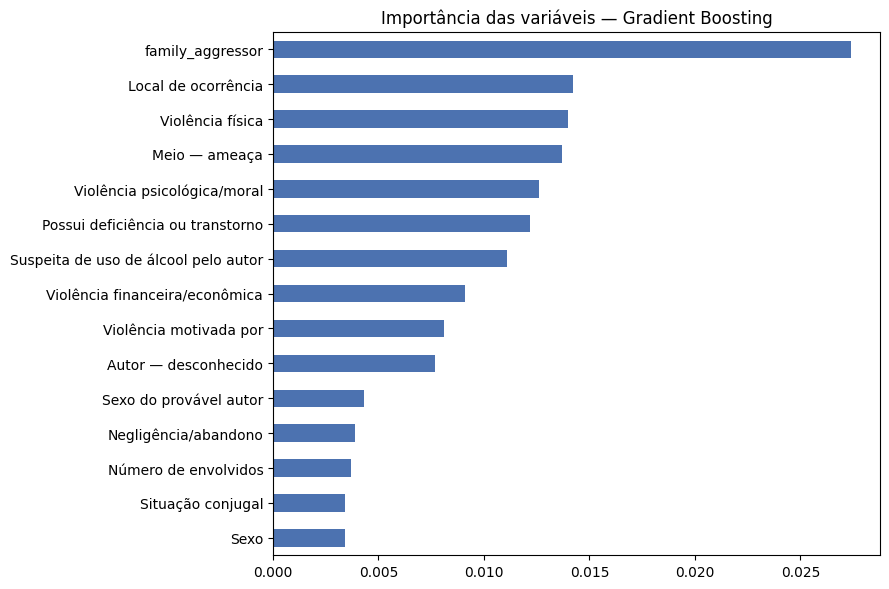

In [17]:
from sklearn.inspection import permutation_importance

importance = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10, random_state=42, scoring="roc_auc", n_jobs=-1,
)

ranking = pd.DataFrame({
    "variável": X_test.columns,
    "nome": [LABELS.get(c, c) for c in X_test.columns],
    "queda no AUC": importance.importances_mean.round(4),
    "desvio": importance.importances_std.round(4),
}).sort_values("queda no AUC", ascending=False)

top = ranking.head(15).sort_values("queda no AUC")

ax = top.plot(kind="barh", x="nome", y="queda no AUC", figsize=(9, 6),
              color="#4C72B0", legend=False,
              title=f"Importância das variáveis — {best_name}")
ax.set_ylabel("")
plt.tight_layout()

ranking.head(20)

In [18]:
# Confirmar que nenhum campo de sensível entrou
leak = [c for c in X.columns if c.startswith(("ENC_", "DELEG_", "CONS_", "PROC_"))]

if leak:
  print("[AVISO] Encontrado campos sensíveis: ", leak)

---
## 8. Exportar o modelo
Exportar o modelo com `.joblib` guardando o pipeline inteiro. O metadado ao lado registra o que foi treinado, com quais dados e qual desempenho.

In [28]:
import joblib
import json
from datetime import date
import sklearn

MODEL_FILE = f"modelo_risco_recorrencia_{YEAR}.joblib"
META_FILE = f"modelo_risco_recorrencia_{YEAR}_metadados.json"

joblib.dump(best_model, MODEL_FILE)

metadata = {
    "modelo": best_name,
    "data_treino": str(date.today()),
    "base": f"SINAN/VIOL {YEAR} — DATASUS",
    "populacao": f"vítimas {MINIMAL_AGE}+, violência interpessoal",
    "alvo": TARGET,
    "n_treino": int(len(X_train)),
    "n_teste": int(len(X_test)),
    "n_variaveis": int(X.shape[1]),
    "n_features_apos_encoding": int(n_features),
    "taxa_recorrencia": round(float(y.mean()), 4),
    "metricas": comparison[comparison["modelo"] == best_name].to_dict("records")[0],
    "variaveis_excluidas": DELETE,
    "versao_sklearn": sklearn.__version__,
    "aviso_uso": (
        "Ferramenta de apoio à triagem humana. Não substitui avaliação profissional e não deve excluir nenhum caso do atendimento."
    ),
}

with open(META_FILE, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f"[INFO] Modelo   : {MODEL_FILE}")
print(f"[INFO] Metadados: {META_FILE}")

# Teste de carga para garantir que o arquivo abre e prevê
reloaded = joblib.load(MODEL_FILE)
check = reloaded.predict_proba(X_test.head(3))[:, 1]
print(f"\n[INFO] Teste de carga OK — probabilidades: {check.round(3)}")

[INFO] Modelo   : modelo_risco_recorrencia_2024.joblib
[INFO] Metadados: modelo_risco_recorrencia_2024_metadados.json

[INFO] Teste de carga OK — probabilidades: [0.219 0.471 0.585]


In [32]:
# Baixar os arquivos
from google.colab import files

# files.download(filename)
files.download(MODEL_FILE)
files.download(META_FILE)
# files.download("features.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Testes


In [26]:
# Teste do alvo embaralhado
from sklearn.model_selection import cross_val_score
import numpy as np

rng = np.random.default_rng(42)
y_shuffled = pd.Series(rng.permutation(y_train.values), index=y_train.index)

auc_fake = cross_val_score(
    Pipeline([("prep", preprocessor), ("clf", HistGradientBoostingClassifier(random_state=42))]),
    X_train, y_shuffled, cv=5, scoring="roc_auc"
).mean()

auc_real = comparison.loc[comparison["modelo"] == best_name, "AUC"].iloc[0]

print(f"AUC com alvo real       : {auc_real:.3f}")
print(f"AUC com alvo embaralhado: {auc_fake:.3f}")
print("OK" if auc_fake < 0.55 else "Erro de pipeline")

AUC com alvo real       : 0.836
AUC com alvo embaralhado: 0.498
OK


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


previsto 6% → observado 7%
previsto 15% → observado 14%
previsto 25% → observado 25%
previsto 35% → observado 39%
previsto 45% → observado 48%
previsto 55% → observado 54%
previsto 65% → observado 63%
previsto 75% → observado 72%
previsto 85% → observado 84%
previsto 93% → observado 93%


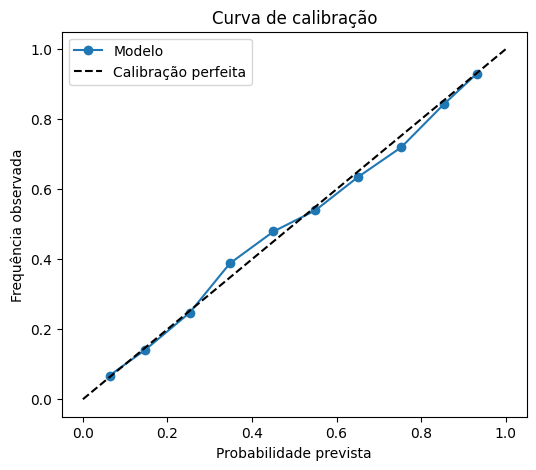

In [22]:
# Calibração
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

proba = best_model.predict_proba(X_test)[:, 1]
real, previsto = calibration_curve(y_test, proba, n_bins=10)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(previsto, real, "o-", label="Modelo")
ax.plot([0, 1], [0, 1], "k--", label="Calibração perfeita")
ax.set_xlabel("Probabilidade prevista")
ax.set_ylabel("Frequência observada")
ax.set_title("Curva de calibração")
ax.legend()

for p, r in zip(previsto, real):
    print(f"previsto {p:.0%} → observado {r:.0%}")

In [23]:
# Coerência dos fatores
alvo = y_train
for col in ["REL_FILHO", "REL_CUIDA", "REL_DESCO", "VIOL_NEGLI",
            "VIOL_PSICO", "VIOL_FISIC", "AUTOR_ALCO"]:
    if col not in X_train.columns:
        continue
    marcado = X_train[col].map(normalize_code) == "1"
    if marcado.sum() < 100:
        continue
    print(f"{col:14s} n={marcado.sum():6,}  "
          f"recorrência: {alvo[marcado].mean():.1%}  "
          f"(base: {alvo.mean():.1%})")

REL_FILHO      n= 7,360  recorrência: 69.0%  (base: 54.6%)
REL_CUIDA      n=   483  recorrência: 68.3%  (base: 54.6%)
REL_DESCO      n= 2,009  recorrência: 11.6%  (base: 54.6%)
VIOL_NEGLI     n= 5,812  recorrência: 61.0%  (base: 54.6%)
VIOL_PSICO     n= 5,541  recorrência: 75.1%  (base: 54.6%)
VIOL_FISIC     n=10,642  recorrência: 44.8%  (base: 54.6%)
AUTOR_ALCO     n= 5,318  recorrência: 60.3%  (base: 54.6%)


In [24]:
# Estabilidade entre sorteios
aucs = []
for seed in [1, 7, 13, 42, 99]:
    Xtr, Xte, ytr, yte = train_test_split(
        X_model, y_model, test_size=0.2, stratify=y_model, random_state=seed
    )
    pipe = Pipeline([("prep", preprocessor),
                     ("clf", HistGradientBoostingClassifier(random_state=42))])
    pipe.fit(Xtr, ytr)
    aucs.append(roc_auc_score(yte, pipe.predict_proba(Xte)[:, 1]))

print(f"AUC por semente: {[round(a, 3) for a in aucs]}")
print(f"Média {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")

AUC por semente: [np.float64(0.835), np.float64(0.839), np.float64(0.838), np.float64(0.836), np.float64(0.848)]
Média 0.839 ± 0.005


0.014 0.988
Casos acima de 0,70: 41.2%
Casos abaixo de 0,30: 27.1%


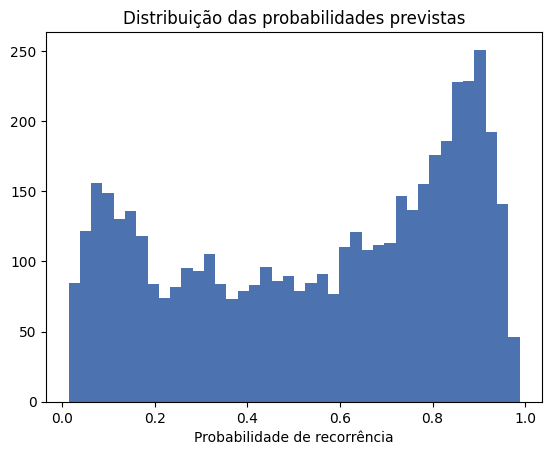

In [25]:
# Distribuição das probabilidades
proba = best_model.predict_proba(X_test)[:, 1]

plt.hist(proba, bins=40, color="#4C72B0")
plt.title("Distribuição das probabilidades previstas")
plt.xlabel("Probabilidade de recorrência")

print(proba.round(3).min(), proba.round(3).max())
print(f"Casos acima de 0,70: {(proba > 0.70).mean():.1%}")
print(f"Casos abaixo de 0,30: {(proba < 0.30).mean():.1%}")